In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import pathlib

In [12]:
folder_path = pathlib.Path("./post/006_fixedSphere_PIBM")
full_params = pd.read_csv(folder_path / "simulation.csv")
results_folder = pathlib.Path("./bin/fixedSpherePIBM")

df_list = []
for idx, case_params in full_params.iterrows():
    files = (results_folder / f"Case_{int(case_params['Case'])}").glob("*.csv")
    cols_to_keep = ["p_number", "step", "f_z"]
    # print([f for f in files])
    df_csv = [pd.read_csv(f, usecols=cols_to_keep) for f in files]
    # print(int(case_params["Case"]))
    try:
        current_df = pd.concat(df_csv, ignore_index=True)
    except:
        continue
    Ap = 3.1415 * case_params["dp"] ** 2
    Re = case_params["u"] * case_params["dp"] / case_params["viscosity"]
    current_df["Cd"] = current_df["f_z"] / (0.5 * case_params["u"] ** 2 * Ap)
    current_df["Re"] = Re
    current_df["Case"] = int(case_params["Case"])
    current_df["dp"] = case_params["dp"]
    current_df["tau"] = case_params["tau"]
    current_df["u"] = case_params["u"]
    df_list.extend([current_df.iloc[-1:]])

    # plt.plot(current_df["step"], current_df["Cd"])
    # # plt.plot([current_df["step"].min(), current_df["step"].max()], [24 / Re, 24 / Re])
    # plt.xlabel("Step")
    # plt.ylabel("Cd")
    # # plt.show()
    # plt.savefig(results_folder / f"Case_{int(case_params['Case'])}_force_graph.png")
    # plt.close()
final_df = pd.concat(df_list, ignore_index=True)
final_df

,p_number,step,f_z,Cd,Re,Case,dp,tau,u
0,0,19000,0.000031,1104.178816,0.001,0,0.10,0.900000,0.001333
1,0,19000,0.000070,2521.230463,0.001,1,0.25,0.900000,0.000533
2,0,19000,0.000108,3867.654385,0.001,2,0.50,0.900000,0.000267
3,0,19000,0.000111,3967.692185,0.001,3,1.00,0.900000,0.000133
4,0,19000,0.000076,2722.627845,0.001,4,2.00,0.900000,0.000067
...,...,...,...,...,...,...,...,...,...
60,0,19000,-0.000343,-6.557583,10.000,60,0.10,0.501732,0.057735
61,0,19000,0.000955,2.917293,10.000,61,0.25,0.504330,0.057735
62,0,19000,0.005882,4.493304,10.000,62,0.50,0.508660,0.057735
63,0,19000,0.015354,2.932546,10.000,63,1.00,0.517321,0.057735


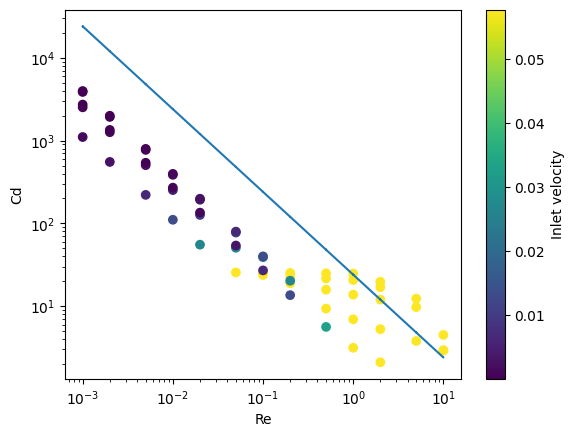

<Figure size 640x480 with 0 Axes>

In [18]:
plt.scatter(
    final_df["Re"],
    final_df["Cd"],
    marker="o",
    c=final_df["u"],
    cmap="viridis",
)
plt.plot(final_df["Re"], 24 / final_df["Re"])
plt.colorbar(label="Inlet velocity")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Re")
plt.ylabel("Cd")
plt.show()
plt.savefig(results_folder / "Cd_inlet_vel.png")

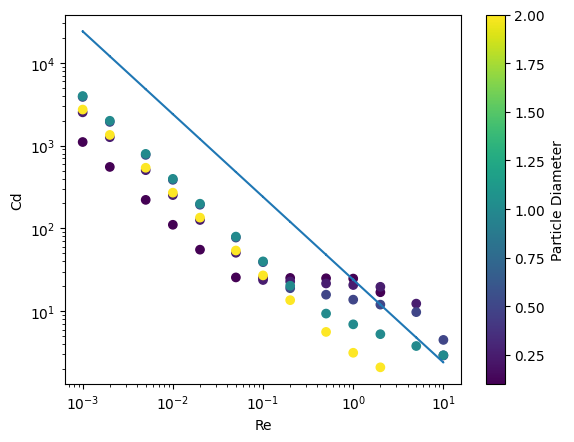

<Figure size 640x480 with 0 Axes>

In [17]:
plt.scatter(
    final_df["Re"],
    final_df["Cd"],
    marker="o",
    c=final_df["dp"],
    cmap="viridis",
)
# for i, x, y in zip(final_df["Case"], final_df["Re"], final_df["Cd"]):
#     plt.annotate(
#         i,  # The label (the index)
#         (x, y),  # The point to label
#         textcoords="offset points",
#         xytext=(0, 7),  # 7 points vertical offset
#         ha="center",  # Center horizontally
#         fontsize=9,
#         fontweight="bold",
#     )
plt.plot(final_df["Re"], 24 / final_df["Re"])
plt.colorbar(label="Particle Diameter")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Re")
plt.ylabel("Cd")
plt.show()
plt.savefig(results_folder / "Cd_diameter.png")

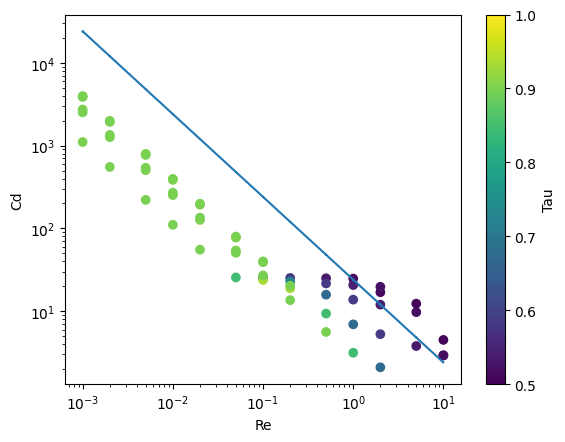

<Figure size 640x480 with 0 Axes>

In [16]:
plt.scatter(
    final_df["Re"],
    final_df["Cd"],
    marker="o",
    c=final_df["tau"],
    cmap="viridis",
)
plt.plot(final_df["Re"], 24 / final_df["Re"])
plt.colorbar(label="Tau")
plt.clim(0.5, 1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Re")
plt.ylabel("Cd")
plt.show()
plt.savefig(results_folder / "Cd_tau.png")

# VTK plot

In [8]:
import pyvista as pv

folder_path = pathlib.Path("./post/006_fixedSphere_PIBM")
full_params = pd.read_csv(folder_path / "simulation.csv")

for idx, case_params in full_params.iterrows():
    try:
        grid = pv.read(
            results_folder
            / f"Case_{int(case_params['Case'])}"
            / f"Case_{int(case_params['Case'])}_vtk020000.vtk"
        )
    except:
        continue
    center = grid.center
    slice_y = grid.slice(normal=[0, 1, 0], origin=center)

    if "velocity" in slice_y.point_data:
        vel_vectors = slice_y.point_data["velocity"]
        slice_y["vel_x"] = vel_vectors[:, 0]
        slice_y["vel_y"] = vel_vectors[:, 1]
        slice_y["vel_z"] = vel_vectors[:, 2]

    for coord in ["x", "y", "z"]:
        plotter = pv.Plotter(shape=(1, 1), off_screen=True)
        plotter.add_mesh(slice_y, scalars=f"vel_{coord}", cmap="viridis")
        plotter.add_text(f"Velocity {coord}")
        plotter.screenshot(
            results_folder / f"Velocity_Case_{int(case_params['Case'])}_{coord}.png"
        )
        plotter.clear()